# Análisis Estadístico - Oposiciones GSI AGE (2018-2024)
### Estudio cuantitativo basado en las Memorias Oficiales de la Comisión Permanente de Selección (CPS) del INAP

Este cuaderno realiza un análisis exhaustivo del **Cuerpo de Gestión de Sistemas e Informática de la Administración del Estado (GSI)**:
- Desglose por convocatorias (2018, 2019, 2022 y 2024).
- Modalidades de acceso (**Ingreso Libre** y **Promoción Interna**).
- Cupos (**General** y **Discapacidad**).
- **Progresión y criba ejercicio a ejercicio** (Superan vs. Caen).
- **Balance histórico global** de aspirantes (2018-2024).
- Impacto de las **OEPs acumuladas** y plazas desiertas.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.autolayout'] = True


## 1. Carga de Datos Oficiales y Cálculo Dinámico de Métricas
Los datos provienen directamente de las Memorias oficiales de la CPS publicadas por el INAP.

In [2]:
df_completo = pd.read_csv('gsi_datos_completos.csv')

# Filtrar subconjuntos cronológicos
df_libre = df_completo[df_completo['tipo_acceso'] == 'Ingreso Libre'].sort_values('convocatoria').copy().reset_index(drop=True)
df_promo = df_completo[df_completo['tipo_acceso'] == 'Promoción Interna'].sort_values('convocatoria').copy().reset_index(drop=True)

# Cálculo de métricas vectorizadas
for d in [df_libre, df_promo]:
    d['tasa_presentacion'] = (d['presentados_1ej_total'] / d['solicitudes_total'] * 100).round(2)
    d['tasa_abandono'] = (100 - d['tasa_presentacion']).round(2)
    d['tasa_exito_global'] = (d['superan_proceso_total'] / d['presentados_1ej_total'] * 100).round(2)
    d['tasa_cobertura'] = (d['superan_proceso_total'] / d['plazas_totales'] * 100).round(2)
    d['plazas_desiertas'] = d['plazas_totales'] - d['superan_proceso_total']
    d['ratio_solicitudes_plaza'] = (d['solicitudes_total'] / d['plazas_totales']).round(2)
    d['ratio_presentados_plaza'] = (d['presentados_1ej_total'] / d['plazas_totales']).round(2)

convocatorias = df_libre['convocatoria'].astype(str).tolist()
x = np.arange(len(convocatorias))
width = 0.35

print("✅ Datos cargados correctamente. Resumen Ingreso Libre:")
cols_resumen = ['convocatoria', 'oep', 'plazas_totales', 'solicitudes_total', 'presentados_1ej_total', 
                'superan_proceso_total', 'plazas_desiertas', 'tasa_presentacion', 'tasa_cobertura', 
                'tasa_exito_global', 'ratio_presentados_plaza']
df_libre[cols_resumen]


✅ Datos cargados correctamente. Resumen Ingreso Libre:


,convocatoria,oep,plazas_totales,solicitudes_total,presentados_1ej_total,superan_proceso_total,plazas_desiertas,tasa_presentacion,tasa_cobertura,tasa_exito_global,ratio_presentados_plaza
0,2018,2018,218,2087,1027,144,74,49.21,66.06,14.02,4.71
1,2019,2019,280,1574,719,143,137,45.68,51.07,19.89,2.57
2,2022,2020-2021-2022,840,2437,1219,316,524,50.02,37.62,25.92,1.45
3,2024,2021-2022-2023-2024,995,2482,1033,410,585,41.62,41.21,39.69,1.04


## 2. Evolución de la Tasa de Éxito Global
Porcentaje de aspirantes presentados al examen que consiguen superar el proceso y obtener plaza.

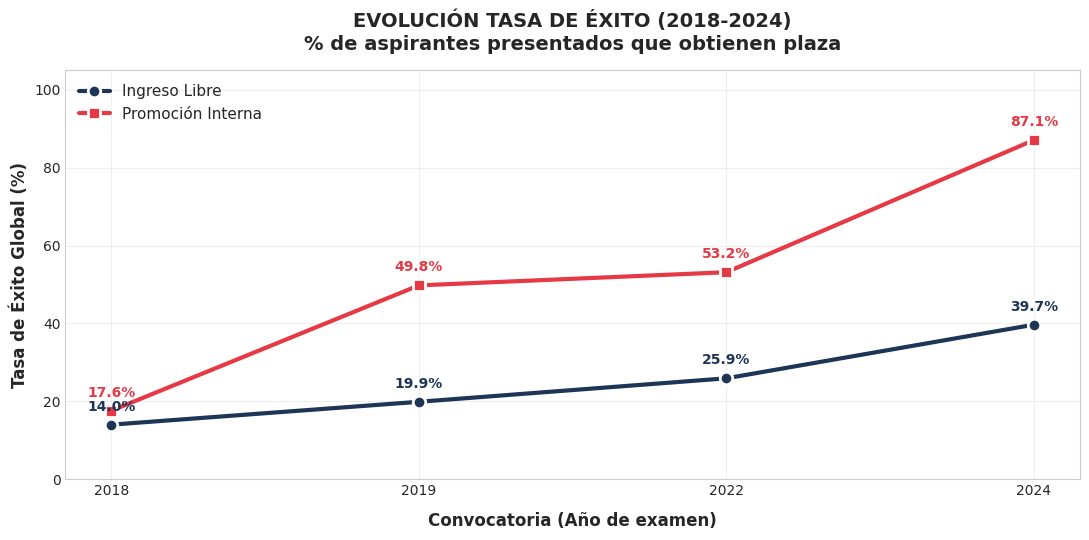

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(convocatorias, df_libre['tasa_exito_global'], 'o-', linewidth=3, markersize=9, 
        label='Ingreso Libre', color='#1D3557', markeredgecolor='white', markeredgewidth=2)
ax.plot(convocatorias, df_promo['tasa_exito_global'], 's-', linewidth=3, markersize=9, 
        label='Promoción Interna', color='#E63946', markeredgecolor='white', markeredgewidth=2)

ax.set_xlabel('Convocatoria (Año de examen)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Tasa de Éxito Global (%)', fontsize=12, fontweight='bold')
ax.set_title('EVOLUCIÓN TASA DE ÉXITO (2018-2024)\n% de aspirantes presentados que obtienen plaza', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)

for i, (v_lib, v_pro) in enumerate(zip(df_libre['tasa_exito_global'], df_promo['tasa_exito_global'])):
    ax.annotate(f'{v_lib:.1f}%', (i, v_lib), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#1D3557')
    ax.annotate(f'{v_pro:.1f}%', (i, v_pro), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color='#E63946')

plt.tight_layout()
plt.show()


## 3. Competitividad: Ratio Teórico vs. Competencia Real
Comparativa entre el ratio de **solicitantes por plaza** (competencia aparente) y el ratio de **presentados por plaza** (competencia real el día del examen).

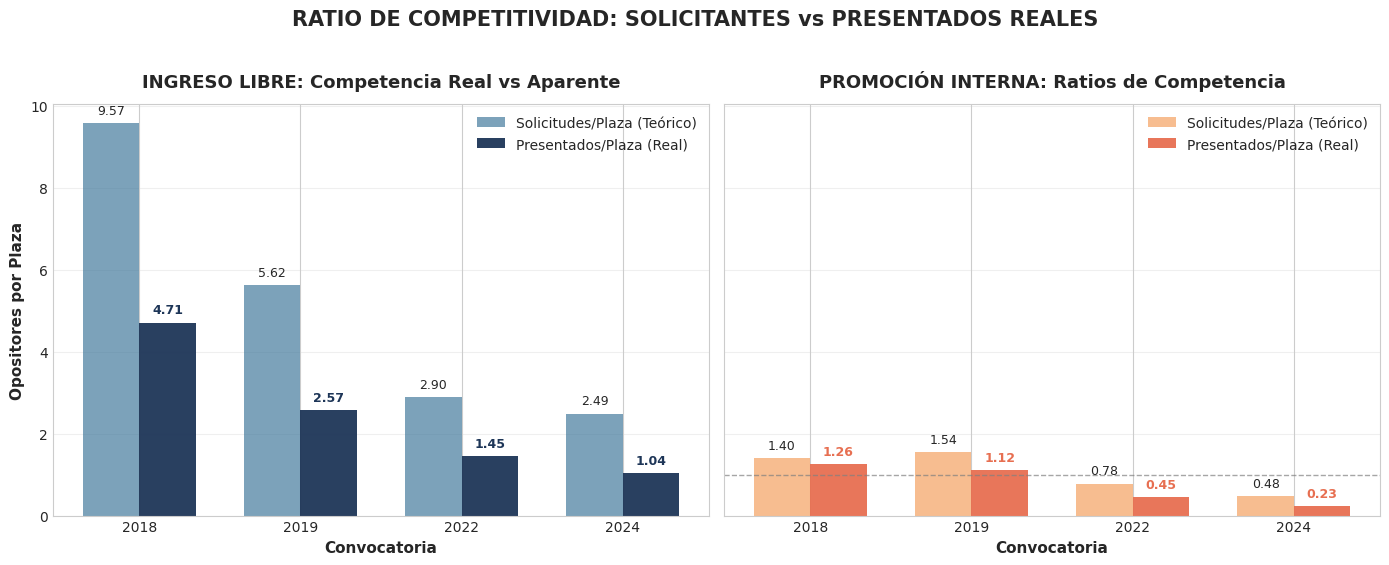

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

# Panel 1: Ingreso Libre
bars_sol_lib = ax1.bar(x - width/2, df_libre['ratio_solicitudes_plaza'], width,
                       label='Solicitudes/Plaza (Teórico)', color='#457B9D', alpha=0.7)
bars_pres_lib = ax1.bar(x + width/2, df_libre['ratio_presentados_plaza'], width,
                        label='Presentados/Plaza (Real)', color='#1D3557', alpha=0.95)

ax1.set_title('INGRESO LIBRE: Competencia Real vs Aparente', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Opositores por Plaza', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(convocatorias, fontsize=10)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars_sol_lib:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.15, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars_pres_lib:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.15, f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1D3557')

# Panel 2: Promoción Interna
bars_sol_pro = ax2.bar(x - width/2, df_promo['ratio_solicitudes_plaza'], width,
                       label='Solicitudes/Plaza (Teórico)', color='#F4A261', alpha=0.7)
bars_pres_pro = ax2.bar(x + width/2, df_promo['ratio_presentados_plaza'], width,
                        label='Presentados/Plaza (Real)', color='#E76F51', alpha=0.95)

ax2.set_title('PROMOCIÓN INTERNA: Ratios de Competencia', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(convocatorias, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Ratio 1:1')

for bar in bars_sol_pro:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.15, f'{h:.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars_pres_pro:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.15, f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#E76F51')

plt.suptitle('RATIO DE COMPETITIVIDAD: SOLICITANTES vs PRESENTADOS REALES', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 4. Plazas Convocadas: Cubiertas vs. Desiertas
La tasa de plazas desiertas en GSI es extraordinariamente elevada tanto en Libre (56.6% histórico) como en Promoción Interna (74.3% histórico).

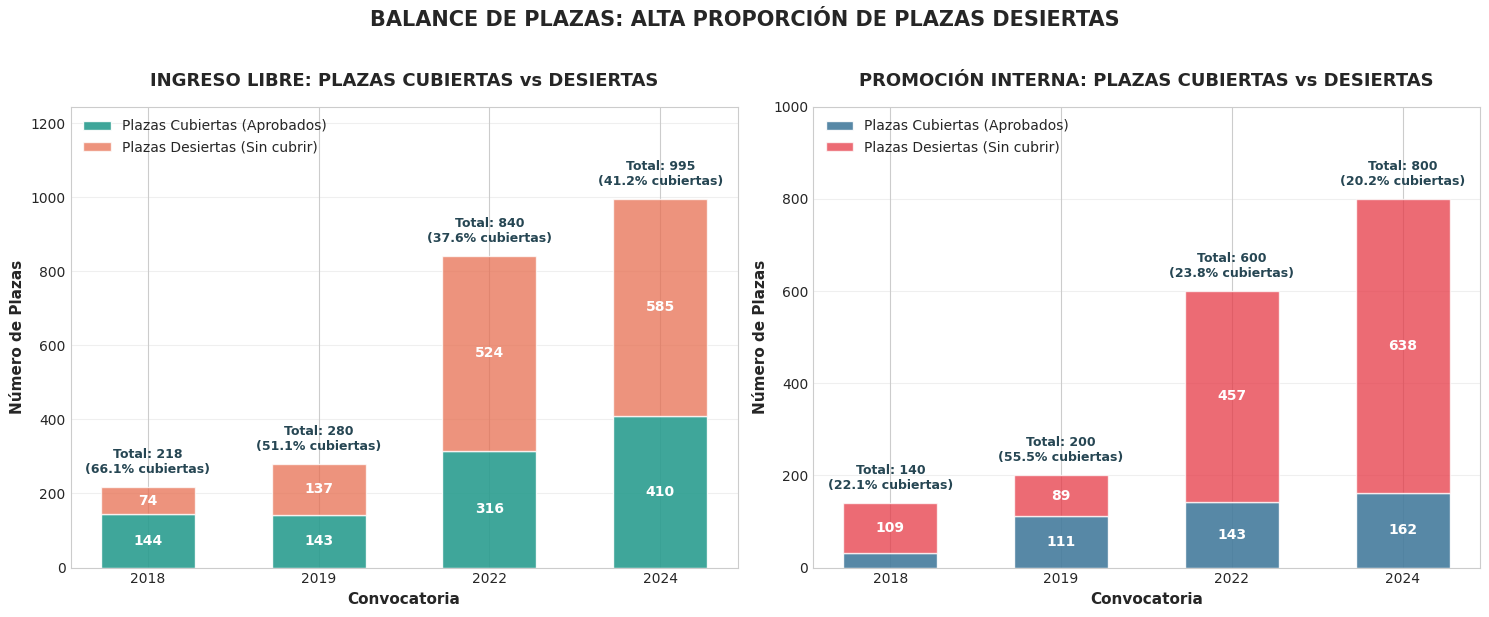

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

def plot_stacked_cobertura(ax, df_sub, titulo, color_cubiertas='#2A9D8F', color_desiertas='#E76F51'):
    cubiertas = df_sub['superan_proceso_total'].values
    desiertas = df_sub['plazas_desiertas'].values
    plazas = df_sub['plazas_totales'].values
    cobertura = df_sub['tasa_cobertura'].values
    
    b1 = ax.bar(x, cubiertas, width=0.55, label='Plazas Cubiertas (Aprobados)', color=color_cubiertas, alpha=0.9, edgecolor='white')
    b2 = ax.bar(x, desiertas, width=0.55, bottom=cubiertas, label='Plazas Desiertas (Sin cubrir)', color=color_desiertas, alpha=0.75, edgecolor='white')
    
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
    ax.set_ylabel('Número de Plazas', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(convocatorias, fontsize=10)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(plazas) * 1.25)
    
    for i in range(len(df_sub)):
        if cubiertas[i] > 40:
            ax.text(i, cubiertas[i]/2, f'{cubiertas[i]}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        if desiertas[i] > 40:
            ax.text(i, cubiertas[i] + desiertas[i]/2, f'{desiertas[i]}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        ax.text(i, plazas[i] + (max(plazas)*0.03), f'Total: {plazas[i]}\n({cobertura[i]:.1f}% cubiertas)',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#264653')

plot_stacked_cobertura(ax1, df_libre, 'INGRESO LIBRE: PLAZAS CUBIERTAS vs DESIERTAS')
plot_stacked_cobertura(ax2, df_promo, 'PROMOCIÓN INTERNA: PLAZAS CUBIERTAS vs DESIERTAS', '#457B9D', '#E63946')

plt.suptitle('BALANCE DE PLAZAS: ALTA PROPORCIÓN DE PLAZAS DESIERTAS', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Embudo de Conversión (Ingreso Libre)
Comprobación de la pérdida de candidatos etapa por etapa en escala lineal proporcional.

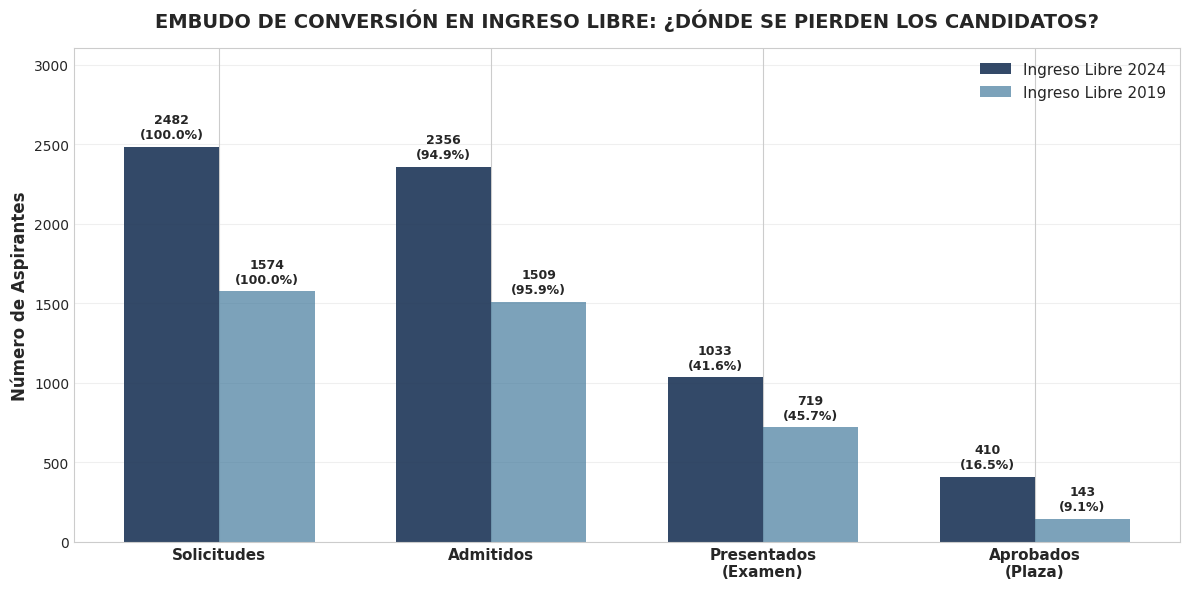

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

etapas = ['Solicitudes', 'Admitidos', 'Presentados\n(Examen)', 'Aprobados\n(Plaza)']

vals_2024 = [
    df_libre.loc[df_libre['convocatoria'] == 2024, 'solicitudes_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2024, 'admitidos_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2024, 'presentados_1ej_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2024, 'superan_proceso_total'].values[0]
]

vals_2019 = [
    df_libre.loc[df_libre['convocatoria'] == 2019, 'solicitudes_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2019, 'admitidos_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2019, 'presentados_1ej_total'].values[0],
    df_libre.loc[df_libre['convocatoria'] == 2019, 'superan_proceso_total'].values[0]
]

x_funnel = np.arange(len(etapas))
w_funnel = 0.35

b_2024 = ax.bar(x_funnel - w_funnel/2, vals_2024, w_funnel, label='Ingreso Libre 2024', color='#1D3557', alpha=0.9)
b_2019 = ax.bar(x_funnel + w_funnel/2, vals_2019, w_funnel, label='Ingreso Libre 2019', color='#457B9D', alpha=0.7)

ax.set_title('EMBUDO DE CONVERSIÓN EN INGRESO LIBRE: ¿DÓNDE SE PIERDEN LOS CANDIDATOS?', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de Aspirantes', fontsize=12, fontweight='bold')
ax.set_xticks(x_funnel)
ax.set_xticklabels(etapas, fontsize=11, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar, base in [(b_2024, vals_2024[0]), (b_2019, vals_2019[0])]:
    for rect in bar:
        h = rect.get_height()
        pct = (h / base) * 100
        ax.text(rect.get_x() + rect.get_width()/2., h + 35, f'{int(h)}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, max(vals_2024) * 1.25)
plt.tight_layout()
plt.show()


## 6. Absentismo Pre-Examen en Ingreso Libre
El porcentaje de opositores que echan la solicitud pero deciden no acudir al examen ronda el 50-58%.

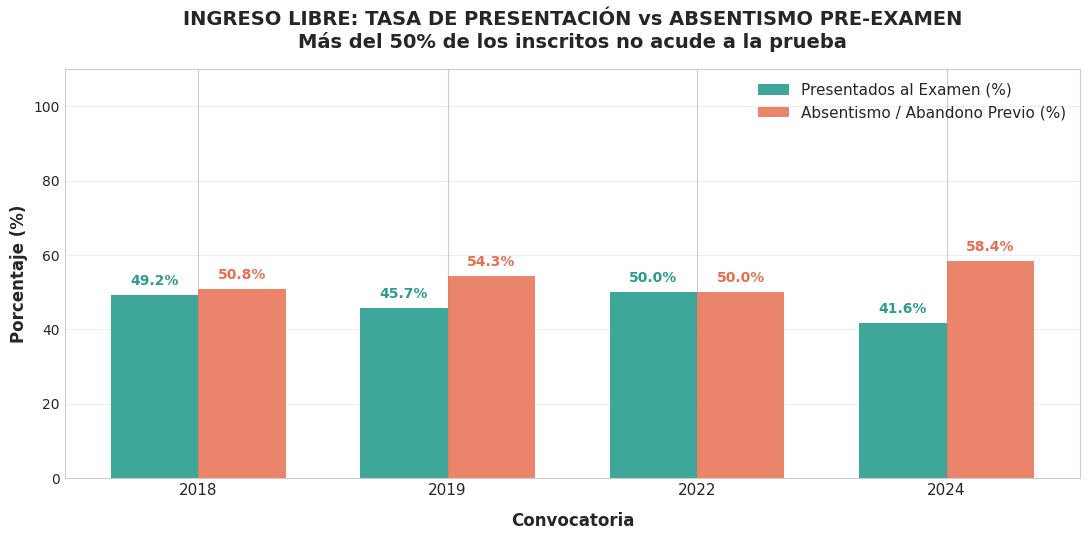

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))

b_pres = ax.bar(x - width/2, df_libre['tasa_presentacion'], width, label='Presentados al Examen (%)', color='#2A9D8F', alpha=0.9)
b_aban = ax.bar(x + width/2, df_libre['tasa_abandono'], width, label='Absentismo / Abandono Previo (%)', color='#E76F51', alpha=0.85)

ax.set_xlabel('Convocatoria', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_title('INGRESO LIBRE: TASA DE PRESENTACIÓN vs ABSENTISMO PRE-EXAMEN\nMás del 50% de los inscritos no acude a la prueba', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(convocatorias, fontsize=11)
ax.legend(fontsize=11, loc='upper right')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')

for bar in b_pres:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 2, f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2A9D8F')
for bar in b_aban:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 2, f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#E76F51')

plt.tight_layout()
plt.show()


## 7. Especial Ingreso Libre: Cupo General vs. Cupo Discapacidad
Análisis comparativo de cobertura y competencia real en el cupo reservado a personas con discapacidad.

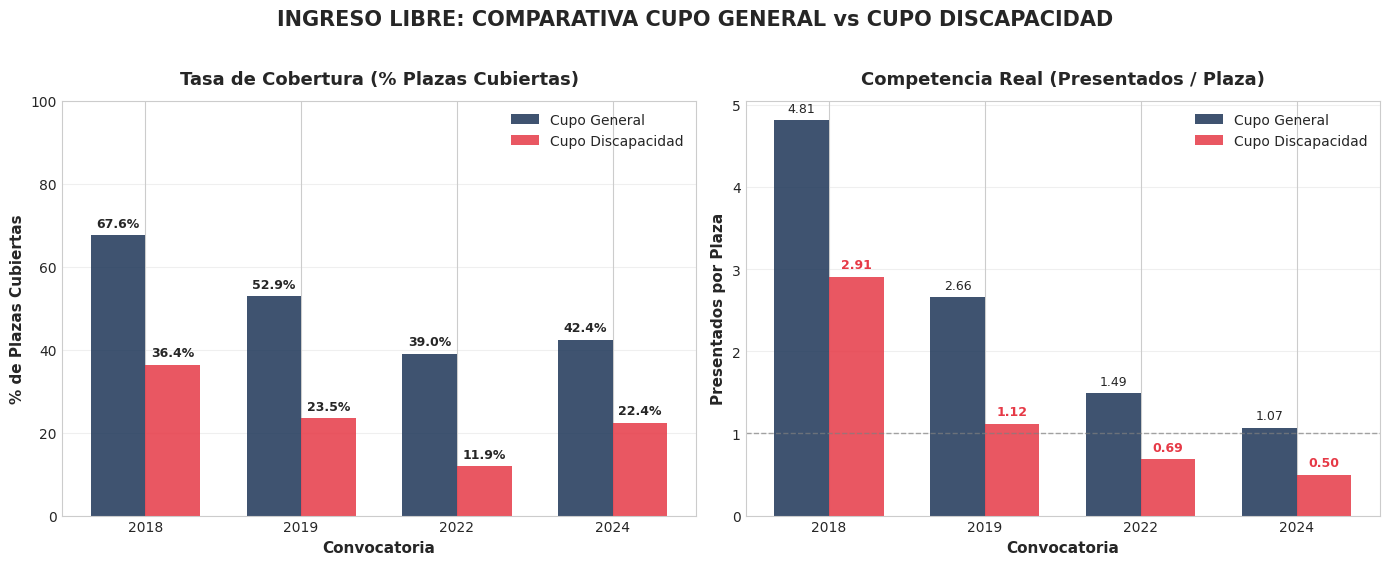

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cobertura_gen = (df_libre['superan_proceso_general'] / df_libre['plazas_general'] * 100).round(1)
cobertura_disc = (df_libre['superan_proceso_discapacidad'] / df_libre['plazas_discapacidad'] * 100).round(1)

b_c_gen = ax1.bar(x - width/2, cobertura_gen, width, label='Cupo General', color='#1D3557', alpha=0.85)
b_c_disc = ax1.bar(x + width/2, cobertura_disc, width, label='Cupo Discapacidad', color='#E63946', alpha=0.85)

ax1.set_title('Tasa de Cobertura (% Plazas Cubiertas)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax1.set_ylabel('% de Plazas Cubiertas', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(convocatorias, fontsize=10)
ax1.set_ylim(0, 100)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

for b in b_c_gen:
    ax1.text(b.get_x() + b.get_width()/2., b.get_height() + 2, f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for b in b_c_disc:
    ax1.text(b.get_x() + b.get_width()/2., b.get_height() + 2, f'{b.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

ratio_p_gen = (df_libre['presentados_1ej_general'] / df_libre['plazas_general']).round(2)
ratio_p_disc = (df_libre['presentados_1ej_discapacidad'] / df_libre['plazas_discapacidad']).round(2)

b_r_gen = ax2.bar(x - width/2, ratio_p_gen, width, label='Cupo General', color='#1D3557', alpha=0.85)
b_r_disc = ax2.bar(x + width/2, ratio_p_disc, width, label='Cupo Discapacidad', color='#E63946', alpha=0.85)

ax2.set_title('Competencia Real (Presentados / Plaza)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax2.set_ylabel('Presentados por Plaza', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(convocatorias, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Ratio 1:1')

for b in b_r_gen:
    ax2.text(b.get_x() + b.get_width()/2., b.get_height() + 0.1, f'{b.get_height():.2f}', ha='center', fontsize=9)
for b in b_r_disc:
    ax2.text(b.get_x() + b.get_width()/2., b.get_height() + 0.1, f'{b.get_height():.2f}', ha='center', fontsize=9, fontweight='bold', color='#E63946')

plt.suptitle('INGRESO LIBRE: COMPARATIVA CUPO GENERAL vs CUPO DISCAPACIDAD', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Especial Ingreso Libre: Desglose por OEP en Convocatorias Acumuladas
Asignación de plazas cubiertas por año de OEP de origen en 2022 y 2024.

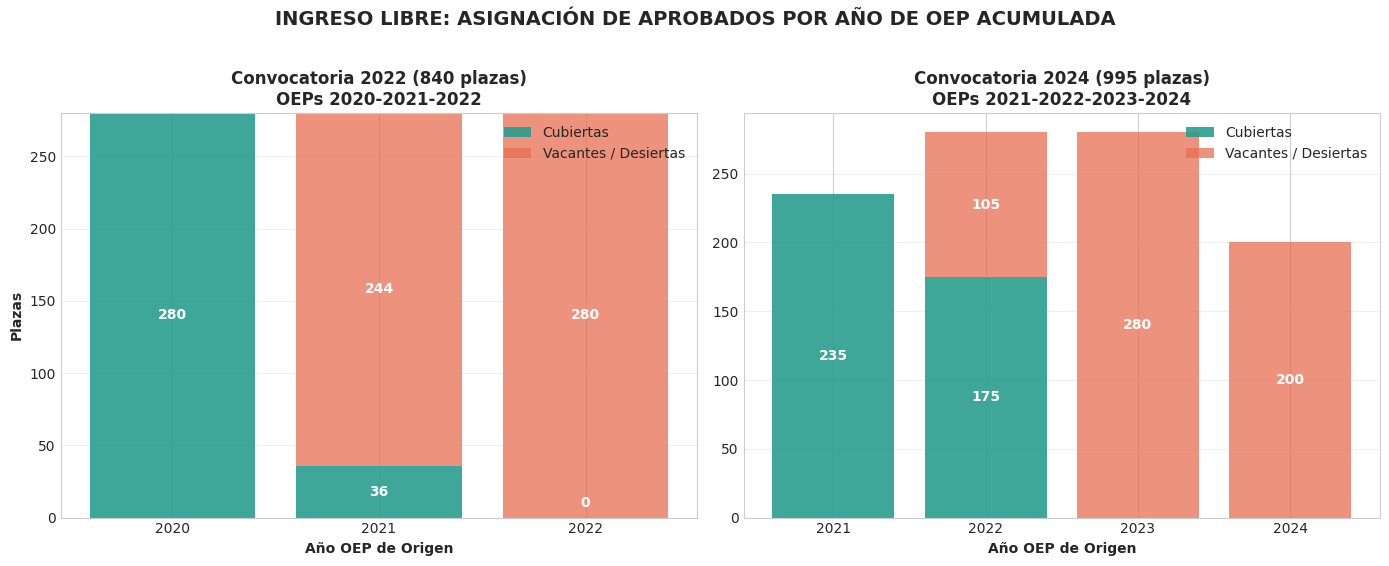

In [9]:
df_oep_raw = pd.read_csv('gsi_oep_desglose_acumuladas.csv')
df_oep_libre = df_oep_raw[df_oep_raw['tipo_acceso'] == 'Ingreso Libre'].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 2022
df_2022 = df_oep_libre[df_oep_libre['convocatoria'] == 2022]
oeps_2022 = df_2022['oep_origen'].astype(str).tolist()
cub_2022 = df_2022['plazas_cubiertas'].values
vac_2022 = df_2022['plazas_vacantes'].values

ax1.bar(oeps_2022, cub_2022, label='Cubiertas', color='#2A9D8F', alpha=0.9)
ax1.bar(oeps_2022, vac_2022, bottom=cub_2022, label='Vacantes / Desiertas', color='#E76F51', alpha=0.75)
ax1.set_title('Convocatoria 2022 (840 plazas)\nOEPs 2020-2021-2022', fontsize=12, fontweight='bold')
ax1.set_xlabel('Año OEP de Origen', fontsize=10, fontweight='bold')
ax1.set_ylabel('Plazas', fontsize=10, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
for i in range(len(oeps_2022)):
    ax1.text(i, cub_2022[i]/2 if cub_2022[i]>20 else 10, f'{cub_2022[i]}', ha='center', va='center', color='white', fontweight='bold')
    if vac_2022[i] > 20:
        ax1.text(i, cub_2022[i] + vac_2022[i]/2, f'{vac_2022[i]}', ha='center', va='center', color='white', fontweight='bold')

# 2024
df_2024 = df_oep_libre[df_oep_libre['convocatoria'] == 2024]
oeps_2024 = df_2024['oep_origen'].astype(str).tolist()
cub_2024 = df_2024['plazas_cubiertas'].values
vac_2024 = df_2024['plazas_vacantes'].values

ax2.bar(oeps_2024, cub_2024, label='Cubiertas', color='#2A9D8F', alpha=0.9)
ax2.bar(oeps_2024, vac_2024, bottom=cub_2024, label='Vacantes / Desiertas', color='#E76F51', alpha=0.75)
ax2.set_title('Convocatoria 2024 (995 plazas)\nOEPs 2021-2022-2023-2024', fontsize=12, fontweight='bold')
ax2.set_xlabel('Año OEP de Origen', fontsize=10, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for i in range(len(oeps_2024)):
    if cub_2024[i] > 20:
        ax2.text(i, cub_2024[i]/2, f'{cub_2024[i]}', ha='center', va='center', color='white', fontweight='bold')
    if vac_2024[i] > 20:
        ax2.text(i, cub_2024[i] + vac_2024[i]/2, f'{vac_2024[i]}', ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('INGRESO LIBRE: ASIGNACIÓN DE APROBADOS POR AÑO DE OEP ACUMULADA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 9. Progresión y Criba Detallada por Ejercicio (2018 y 2019)
En las convocatorias donde los ejercicios se celebraban en fechas separadas, se aprecian dos cribas críticas:
1. **El 1er Ejercicio (Test):** Elimina a algo más del **51%** de los presentados.
2. **El Abandono Inter-Examen:** Entre el **25% y el 30%** de los aspirantes que aprueban el primer ejercicio no se presentan al segundo.
3. **El 2º Ejercicio (Práctico):** Elimina al **45-59%** de los que acuden.

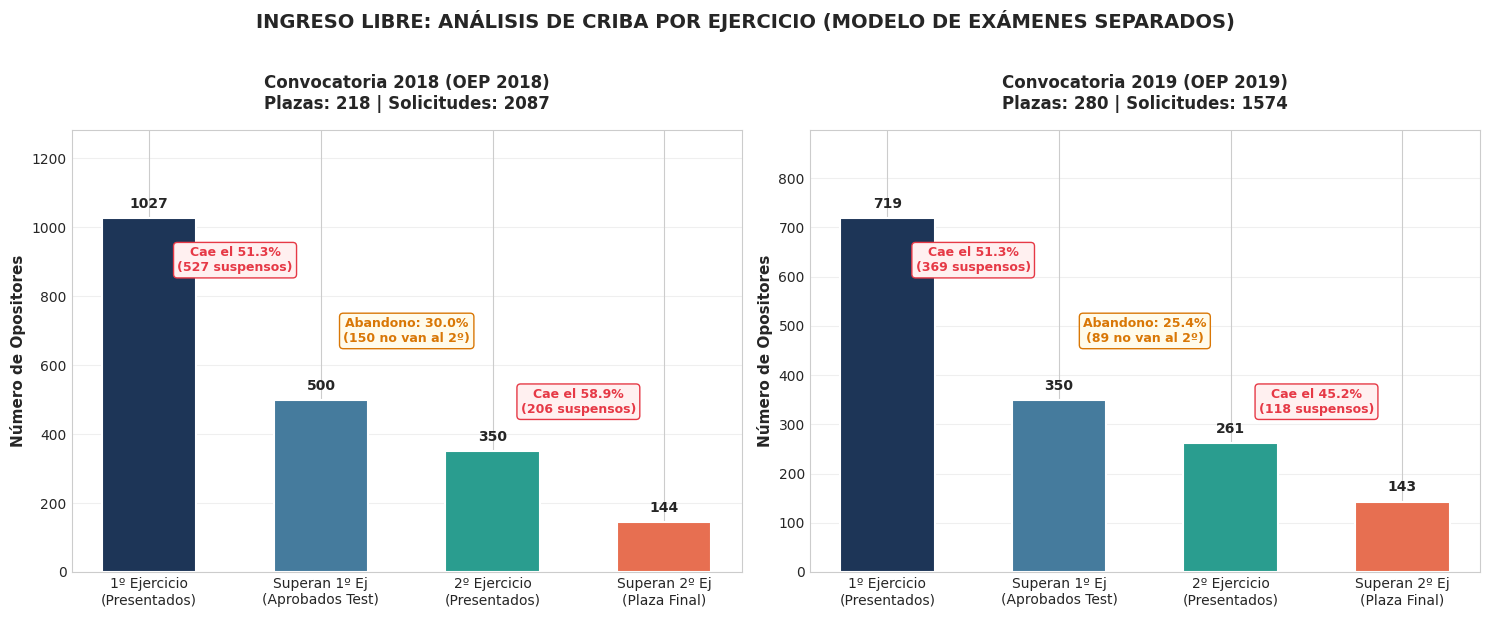

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

def plot_progression_ejercicios(ax, conv_year, titulo):
    r = df_libre[df_libre['convocatoria'] == conv_year].iloc[0]
    p1 = r['presentados_1ej_total']
    s1 = r['superan_1ej_total']
    c1 = p1 - s1
    p2 = r['presentados_2ej_total']
    aban_2 = s1 - p2
    s2 = r['superan_2ej_total']
    c2 = p2 - s2
    
    stages = ['1º Ejercicio\n(Presentados)', 'Superan 1º Ej\n(Aprobados Test)', '2º Ejercicio\n(Presentados)', 'Superan 2º Ej\n(Plaza Final)']
    vals = [p1, s1, p2, s2]
    colors = ['#1D3557', '#457B9D', '#2A9D8F', '#E76F51']
    bars = ax.bar(stages, vals, color=colors, width=0.55, edgecolor='white', linewidth=1.5)
    
    ax.set_title(f'Convocatoria {conv_year} (OEP {r["oep"]})\nPlazas: {r["plazas_totales"]} | Solicitudes: {r["solicitudes_total"]}', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('Número de Opositores', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, p1 * 1.25)
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + (p1*0.02), f'{int(h)}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.annotate(f'Cae el {c1/p1*100:.1f}%\n({int(c1)} suspensos)', 
                xy=(0.5, (p1 + s1)/2), xytext=(0.5, p1*0.85),
                ha='center', fontsize=9, fontweight='bold', color='#E63946',
                bbox=dict(boxstyle="round,pad=0.3", fc="#FFF0F0", ec="#E63946", lw=1))
    
    ax.annotate(f'Abandono: {aban_2/s1*100:.1f}%\n({int(aban_2)} no van al 2º)', 
                xy=(1.5, (s1 + p2)/2), xytext=(1.5, p1*0.65),
                ha='center', fontsize=9, fontweight='bold', color='#D97706',
                bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBEB", ec="#D97706", lw=1))
    
    ax.annotate(f'Cae el {c2/p2*100:.1f}%\n({int(c2)} suspensos)', 
                xy=(2.5, (p2 + s2)/2), xytext=(2.5, p1*0.45),
                ha='center', fontsize=9, fontweight='bold', color='#E63946',
                bbox=dict(boxstyle="round,pad=0.3", fc="#FFF0F0", ec="#E63946", lw=1))

plot_progression_ejercicios(ax1, 2018, 'Criba Ejercicio a Ejercicio - 2018')
plot_progression_ejercicios(ax2, 2019, 'Criba Ejercicio a Ejercicio - 2019')

plt.suptitle('INGRESO LIBRE: ANÁLISIS DE CRIBA POR EJERCICIO (MODELO DE EXÁMENES SEPARADOS)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10. Destino de los Candidatos: Superan vs. Caen (Por Convocatoria e Histórico)
¿Qué ocurre exactamente con cada 100 personas que deciden inscribirse en la oposición?

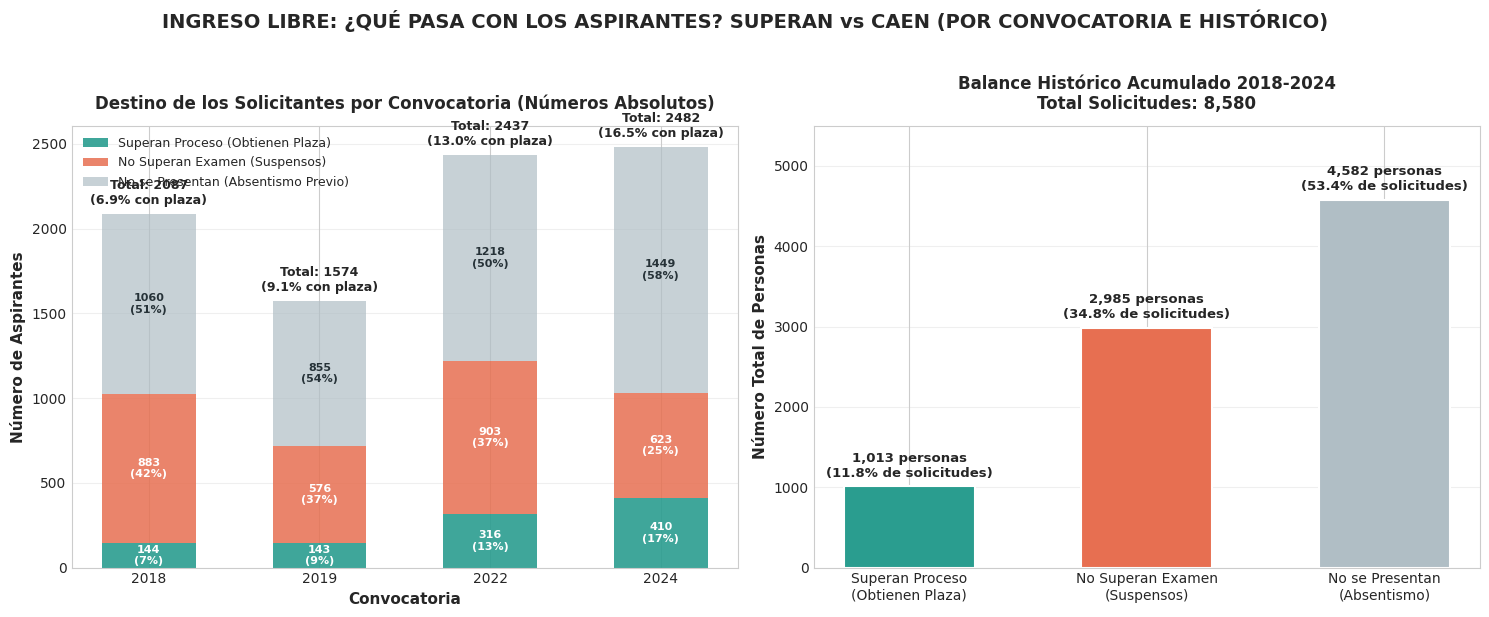

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

convs = df_libre['convocatoria'].astype(str).tolist()
sol = df_libre['solicitudes_total'].values
pres = df_libre['presentados_1ej_total'].values
aprob = df_libre['superan_proceso_total'].values

no_pres = sol - pres
susp = pres - aprob

pct_aprob = (aprob / sol * 100)
pct_susp = (susp / sol * 100)
pct_no_pres = (no_pres / sol * 100)

w = 0.55
b1 = ax1.bar(x, aprob, w, label='Superan Proceso (Obtienen Plaza)', color='#2A9D8F', alpha=0.9)
b2 = ax1.bar(x, susp, w, bottom=aprob, label='No Superan Examen (Suspensos)', color='#E76F51', alpha=0.85)
b3 = ax1.bar(x, no_pres, w, bottom=aprob + susp, label='No se Presentan (Absentismo Previo)', color='#B0BEC5', alpha=0.7)

ax1.set_title('Destino de los Solicitantes por Convocatoria (Números Absolutos)', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Convocatoria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Número de Aspirantes', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(convs, fontsize=10)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

for i in range(len(convs)):
    ax1.text(i, sol[i] + 40, f'Total: {sol[i]}\n({pct_aprob[i]:.1f}% con plaza)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    if aprob[i] > 60:
        ax1.text(i, aprob[i]/2, f'{aprob[i]}\n({pct_aprob[i]:.0f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=8)
    if susp[i] > 100:
        ax1.text(i, aprob[i] + susp[i]/2, f'{susp[i]}\n({pct_susp[i]:.0f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=8)
    if no_pres[i] > 100:
        ax1.text(i, aprob[i] + susp[i] + no_pres[i]/2, f'{no_pres[i]}\n({pct_no_pres[i]:.0f}%)', ha='center', va='center', color='#263238', fontweight='bold', fontsize=8)

tot_sol = sol.sum()
tot_p1 = pres.sum()
tot_aprob = aprob.sum()
tot_susp = susp.sum()
tot_no_pres = no_pres.sum()

categories = ['Superan Proceso\n(Obtienen Plaza)', 'No Superan Examen\n(Suspensos)', 'No se Presentan\n(Absentismo)']
totals = [tot_aprob, tot_susp, tot_no_pres]
tot_pcts = [tot_aprob/tot_sol*100, tot_susp/tot_sol*100, tot_no_pres/tot_sol*100]
colors_bar = ['#2A9D8F', '#E76F51', '#B0BEC5']

b_hist = ax2.bar(categories, totals, color=colors_bar, width=0.55, edgecolor='white', linewidth=1.5)
ax2.set_title(f'Balance Histórico Acumulado 2018-2024\nTotal Solicitudes: {tot_sol:,}', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Número Total de Personas', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(totals) * 1.2)

for bar, pct in zip(b_hist, tot_pcts):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 80, f'{int(h):,} personas\n({pct:.1f}% de solicitudes)',
             ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.suptitle('INGRESO LIBRE: ¿QUÉ PASA CON LOS ASPIRANTES? SUPERAN vs CAEN (POR CONVOCATORIA E HISTÓRICO)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 11. Conclusiones Estratégicas para el Opositor de Ingreso Libre

1. **Balance Histórico Acumulado (8.580 solicitudes en 4 convocatorias):**
   - **53.4% (4.582 personas)** abandonan antes del examen (filtro del absentismo).
   - **34.8% (2.985 personas)** se presentan pero caen en las pruebas (no superan el corte).
   - **11.8% (1.013 personas)** superan el proceso y obtienen plaza fija.
   - De los que acuden al examen, **1 de cada 4 (25.3%)** consigue la plaza.
2. **Criba por ejercicio:** En el modelo de dos ejercicios, el primer ejercicio tipo test actúa como un filtro implacable que suspende a más del **51%** de los presentados. Además, un **25-30%** de los que aprueban el test no acudían al segundo ejercicio por falta de preparación del supuesto práctico.
3. **El impacto del Examen Único (2022 y 2024):** Al realizar ambos exámenes en la misma jornada, se eliminó el abandono inter-examen, aumentando la tasa de éxito final sobre los presentados del 14-20% histórico al 26-40%.
4. **El verdadero rival:** En 2024 quedaron **585 plazas desiertas (58.8%)** con un ratio real de **1.04 presentados por plaza**. El aspirante no compite por desbancar a los demás, sino por superar la nota mínima del Tribunal.
